In [369]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [370]:
data = pd.read_csv("Commodity_Prices_cwa.csv")
df1 = data;

In [371]:
df1.head()

,Market,Commodity,Variety,Grade,Arrival_Date,Min_Price,Max_Price,Modal_Price,Commodity_Code,Unnamed: 9
0,Chhindwara,Green Gram Dal (Moong Dal),Green gram,FAQ,05-11-2024,7001,7001.0,7001.0,265,NaN
1,Chaurai,Wheat,Mill Quality,FAQ,12-06-2024,2400,24421.0,2445.0,1,NaN
2,Pandhurna,Maize,Local,FAQ,27-03-2018,3350,3965.0,3711.0,4,NaN
3,Chaurai,Maize,Other,FAQ,20-07-2013,3400,3550.0,3475.0,4,NaN
4,Chhindwara,Maize,Yellow,FAQ,08-11-2012,2775,3260.0,3180.0,4,NaN


In [372]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132517 entries, 0 to 132516
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Market          132517 non-null  object 
 1   Commodity       132517 non-null  object 
 2   Variety         132517 non-null  object 
 3   Grade           132517 non-null  object 
 4   Arrival_Date    132517 non-null  object 
 5   Min_Price       132517 non-null  int64  
 6   Max_Price       132517 non-null  float64
 7   Modal_Price     132517 non-null  float64
 8   Commodity_Code  132517 non-null  int64  
 9   Unnamed: 9      0 non-null       float64
dtypes: float64(3), int64(2), object(5)
memory usage: 10.1+ MB


In [373]:
#dropping the last column
df1.drop(data.columns[data.columns.str.contains('unnamed', case=False)], axis=1, inplace=True)

In [374]:
# seperate column for market type(F&V)
df1["Market_type"] = df1["Market"].apply(lambda x : "F&V" if "(F&V)" in x else "Grains")

In [375]:
# and moving it to second
df2 = df1.iloc[:, [0, 9, 8, 1, 2, 3, 4, 5, 6, 7]]
# df2.info()

In [376]:
# df2["Market_type"].unique() 
df2.iloc[:,0].unique()

array(['Chhindwara', 'Chaurai', 'Pandhurna', 'Chhindwara(F&V)', 'Sausar',
       'Amarwada', 'Sausar(F&V)', 'Pandhurna(F&V)'], dtype=object)

In [377]:
#fixing different codes and commodity names
len(df2.iloc[:,2].unique()) #114
len(df2.iloc[:,3].unique()) #112

112

In [378]:
ls = data.groupby("Commodity")["Commodity_Code"].unique()
# print(type(ls))
ls.iloc[: ,]
dict1 = {k : v for k, v in ls.items() if len(v) > 1}
dict1

{'Kutki': array([426, 415], dtype=int64),
 'Moath Dal': array([258,  95], dtype=int64)}

In [379]:
#extracting ids , and its comm name
double_ids = [x for i in dict1.values() for x in i]
double_ids

[426, 415, 258, 95]

In [380]:
dict2 = {i : data.loc[df2["Commodity_Code"] == i, "Commodity"].values for i in double_ids}
dict2
#its safe to keep one id of each

{426: array(['Kutki', 'Kutki'], dtype=object),
 415: array(['Kutki', 'Kutki'], dtype=object),
 258: array(['Moath Dal', 'Moath Dal', 'Moath Dal', 'Moath Dal', 'Moath Dal',
        'Moath Dal', 'Moath Dal', 'Moath Dal', 'Moath Dal', 'Moath Dal',
        'Moath Dal', 'Moath Dal', 'Moath Dal', 'Moath Dal', 'Moath Dal'],
       dtype=object),
 95: array(['Moath Dal', 'Moath Dal', 'Moath Dal', 'Moath Dal', 'Moath Dal',
        'Moath Dal', 'Moath Dal', 'Moath Dal', 'Moath Dal', 'Moath Dal',
        'Moath Dal', 'Moath Dal', 'Moath Dal'], dtype=object)}

In [381]:
#keep one ids of commodities having multiple ids
df3 = df2
df3.loc[df3["Commodity_Code"] == 426, "Commodity_Code"] = 415
df3.loc[df3["Commodity_Code"] == 258, "Commodity_Code"] = 95
# df3.loc[df3["Commodity_Code"] == 95]

In [382]:
#check and fix Grains are not in F&Vs
df4 = df3.copy()
both_market = df3.groupby("Commodity")["Market_type"].agg(pd.Series.mode)
df4.loc[ :, "Market_type"] = df4["Commodity"].apply(lambda x : both_market[x])

In [383]:
df5 = df4.copy()

In [384]:
#as the new F&Vs might have added fix their Market_Name
def fix_market(row):
    if row["Market_type"] == "F&V" and not (row["Market"][-5:] == ("(F&V)")):
        return row["Market"]+"(F&V)"
    elif row["Market_type"] == "Grains" and (row["Market"][-5:] == ("(F&V)")):
        return row["Market"][:-5]
    else:
        return row["Market"]
    
df5.loc[:, "Market"] = df5.apply(lambda x : fix_market(x), axis = 1)

# st = "chaurai(f&v)"
# st[-5:]

In [385]:
#fix zero prices

In [386]:
df6 = df5.copy()

In [387]:
#fixing prices that are zero
# if 0 min price and max also 0, then put modal price
# if 0 min price -> adjust it accourding to modal price and max price
# if 0 max price -> adjust it accourding to modal price and min price

def fix_price(row):
    if (row["Min_Price"] + row["Max_Price"]) == 0:
        row["Min_Price"] = row["Modal_Price"]
        row["Max_Price"] = row["Modal_Price"]
    elif row["Min_Price"] == 0:
        row["Min_Price"] = row["Modal_Price"]*2 - row["Max_Price"]
    elif row["Max_Price"] == 0:
        row["Max_Price"] = row["Modal_Price"]*2 - row["Min_Price"]
    return row
        
df6 = df6.apply(lambda x : fix_price(x), axis = 1)
# df6[df6["Max_Price"] == 0]

In [388]:
#make separate column for available since date
df7 = df6.copy()
df7['Arrival_Date'] = pd.to_datetime(df7['Arrival_Date'], format='%d-%m-%Y')

In [389]:
df7["First_Date"] = df7.groupby("Commodity")["Arrival_Date"].transform("min")
df7.head()

,Market,Market_type,Commodity_Code,Commodity,Variety,Grade,Arrival_Date,Min_Price,Max_Price,Modal_Price,First_Date
0,Chhindwara,Grains,265,Green Gram Dal (Moong Dal),Green gram,FAQ,2024-11-05,7001.0,7001.0,7001.0,2006-06-10
1,Chaurai,Grains,1,Wheat,Mill Quality,FAQ,2024-06-12,2400.0,24421.0,2445.0,2002-07-08
2,Pandhurna,Grains,4,Maize,Local,FAQ,2018-03-27,3350.0,3965.0,3711.0,2002-07-08
3,Chaurai,Grains,4,Maize,Other,FAQ,2013-07-20,3400.0,3550.0,3475.0,2002-07-08
4,Chhindwara,Grains,4,Maize,Yellow,FAQ,2012-11-08,2775.0,3260.0,3180.0,2002-07-08


In [390]:
#column for the years of data present for each commodity
# df7.tail()

In [391]:
df7["Years_Age"]=df7.loc[:, "Arrival_Date"].dt.year - df7.loc[:, "First_Date"].dt.year
# df7.head()

In [392]:
df8 = df7.iloc[:, [0, 1, 2, 3, 4, 5, 6, 10, 11, 7, 8, 9]]

In [393]:
df8

,Market,Market_type,Commodity_Code,Commodity,Variety,Grade,Arrival_Date,First_Date,Years_Age,Min_Price,Max_Price,Modal_Price
0,Chhindwara,Grains,265,Green Gram Dal (Moong Dal),Green gram,FAQ,2024-11-05,2006-06-10,18,7001.0,7001.0,7001.0
1,Chaurai,Grains,1,Wheat,Mill Quality,FAQ,2024-06-12,2002-07-08,22,2400.0,24421.0,2445.0
2,Pandhurna,Grains,4,Maize,Local,FAQ,2018-03-27,2002-07-08,16,3350.0,3965.0,3711.0
3,Chaurai,Grains,4,Maize,Other,FAQ,2013-07-20,2002-07-08,11,3400.0,3550.0,3475.0
4,Chhindwara,Grains,4,Maize,Yellow,FAQ,2012-11-08,2002-07-08,10,2775.0,3260.0,3180.0
...,...,...,...,...,...,...,...,...,...,...,...,...
132512,Chhindwara(F&V),F&V,24,Potato,Other,FAQ,2015-12-11,2002-07-11,13,500.0,680.0,590.0
132513,Chhindwara(F&V),F&V,35,Brinjal,Other,FAQ,2011-09-13,2010-09-28,1,400.0,600.0,500.0
132514,Chhindwara(F&V),F&V,23,Onion,Other,FAQ,2009-02-26,2002-07-11,7,300.0,7700.0,4000.0
132515,Chhindwara(F&V),F&V,154,Cabbage,Other,FAQ,2012-03-28,2008-07-15,4,200.0,250.0,225.0


# Moving on to specific commodities

In [394]:
# -------------------------------
# -------------------------------
files = {
    'Arhar':    'datasets/1arhar_tur_red_gram.csv',
    'Maize':   'datasets/4maize.csv',
    'Soyabean': 'datasets/6soyabean.csv',
    'Wheat':   'datasets/7wheat.csv',
}

cleaned_new = {}

for crop, filepath in files.items():
    print(f"\n=== {crop} ===")
    try:
        df_new = pd.read_csv(filepath)
        print("Shape:", df_new.shape)
        new_header = df_new.iloc[0].values
        df_new.columns = new_header
        df_new = df_new[1:]
        df_new = df_new.reset_index(drop=True) 

        # Rename important columns
        df_new = df_new.rename(columns={
            "Date": "Arrival_Date",
            "Modal Price 01-01-2025 to 25-02-2026": "Modal_Price",
            "Arrival Quantity 01-01-2025 to 25-02-2026": "Arrival_Quantity_MT",
            "Commodity Group" : "Commodity_Group"
        })
        df_new['Arrival_Date'] = pd.to_datetime(df_new['Arrival_Date'], format='%d-%m-%Y', errors='coerce')
        
        
        #drop columns
        df_new.drop(columns=["Arrival Unit", "Price Unit", "State", "District"], inplace=True)

        # Add fixed columns for consistency with old data
        df_new['Market'] = 'Chhindwara_District'  # to differentiate from old individual mandis

        # Select only useful columns (focus on new data priority)
        keep_cols = ['Arrival_Date', 'Market', 'Commodity', 'Modal_Price', 'Arrival_Quantity_MT']
        df_new = df_new[keep_cols + [col for col in df_new if col not in keep_cols]]  # order nice

        # Sort by date
        df_new = df_new.sort_values('Arrival_Date').reset_index(drop=True)

        print(f"Missing Modal_Price before fill: {df_new['Modal_Price'].isna().sum()}")
        df_new = df_new.ffill()
        
        #dropping duplicates
        df_new = df_new.drop_duplicates()
        
        print(f"\n{crop} cleaned shape: {df_new.shape}")
        print(df_new.head(3))
        print("Sample rows:")
        print(df_new.head(3))
        
        cleaned_new[crop] = df_new
        print("-"*60)
    except Exception as e: 
        print("Error loading", filepath, "→", str(e))


=== Arhar ===
Shape: (242, 9)
Missing Modal_Price before fill: 2

Arhar cleaned shape: (239, 6)
  Arrival_Date               Market                   Commodity Modal_Price  \
0   2025-01-07  Chhindwara_District  Arhar(Tur/Red Gram)(Whole)     6360.00   
1   2025-01-09  Chhindwara_District  Arhar(Tur/Red Gram)(Whole)     5900.00   
2   2025-01-15  Chhindwara_District  Arhar(Tur/Red Gram)(Whole)     6891.00   

  Arrival_Quantity_MT Commodity_Group  
0                0.40          Pulses  
1                0.20          Pulses  
2                0.20          Pulses  
Sample rows:
  Arrival_Date               Market                   Commodity Modal_Price  \
0   2025-01-07  Chhindwara_District  Arhar(Tur/Red Gram)(Whole)     6360.00   
1   2025-01-09  Chhindwara_District  Arhar(Tur/Red Gram)(Whole)     5900.00   
2   2025-01-15  Chhindwara_District  Arhar(Tur/Red Gram)(Whole)     6891.00   

  Arrival_Quantity_MT Commodity_Group  
0                0.40          Pulses  
1               

In [395]:
cleaned_new["Wheat"].duplicated().any()

False

In [396]:
df8.head()

,Market,Market_type,Commodity_Code,Commodity,Variety,Grade,Arrival_Date,First_Date,Years_Age,Min_Price,Max_Price,Modal_Price
0,Chhindwara,Grains,265,Green Gram Dal (Moong Dal),Green gram,FAQ,2024-11-05,2006-06-10,18,7001.0,7001.0,7001.0
1,Chaurai,Grains,1,Wheat,Mill Quality,FAQ,2024-06-12,2002-07-08,22,2400.0,24421.0,2445.0
2,Pandhurna,Grains,4,Maize,Local,FAQ,2018-03-27,2002-07-08,16,3350.0,3965.0,3711.0
3,Chaurai,Grains,4,Maize,Other,FAQ,2013-07-20,2002-07-08,11,3400.0,3550.0,3475.0
4,Chhindwara,Grains,4,Maize,Yellow,FAQ,2012-11-08,2002-07-08,10,2775.0,3260.0,3180.0


In [397]:
np.sort(df8.columns)

array(['Arrival_Date', 'Commodity', 'Commodity_Code', 'First_Date',
       'Grade', 'Market', 'Market_type', 'Max_Price', 'Min_Price',
       'Modal_Price', 'Variety', 'Years_Age'], dtype=object)

# Data Final Cleanup & Preparation

In [398]:
# relevant columns from old to match new
old_keep = ['Arrival_Date','Commodity', 'Market', 'Market_type', 'Years_Age', 'Modal_Price']
df_old = df8[old_keep].copy()
df_old['Arrival_Quantity_MT'] = np.nan   # old mein nahi tha
df_old['Commodity_Group'] = np.nan
df_old["Commodity"] = df_old["Commodity"].replace("Arhar (Tur/Red Gram)(Whole)", "Arhar")


# For district-level: if old has multiple mandis, average per date + commodity
df_old_district = df_old.groupby(['Arrival_Date', 'Commodity']).agg({
    'Modal_Price': 'mean',
    'Market': lambda x: 'Chhindwara_District (old avg)',
}).reset_index()
df_old_district['Arrival_Quantity_MT'] = np.nan
df_old_district['Commodity_Group'] = np.nan  # can fill later

# merge per crop
merged_dfs = {}

for crop in ['Arhar', 'Maize', 'Soyabean', 'Wheat']:
    df_new_crop = cleaned_new[crop]
    
    # Filter old for this crop
    df_old_crop = df_old_district[df_old_district['Commodity'] == crop].copy()
    
    # Concat old + new
    df_merged = pd.concat([df_old_crop, df_new_crop], ignore_index=True)
    
    # Sort by date
    df_merged = df_merged.sort_values('Arrival_Date').reset_index(drop=True)
    
    # fill remaining gaps
    df_merged['Modal_Price'] = df_merged['Modal_Price'].ffill().bfill()
    df_merged['Arrival_Quantity_MT'] = df_merged['Arrival_Quantity_MT'].fillna(0)
    df_merged['Commodity_Group'] = df_merged['Commodity_Group'].ffill().bfill()

    # numeric columns
    df_merged['Modal_Price'] = pd.to_numeric(df_merged['Modal_Price'], errors='coerce')
    df_merged['Arrival_Quantity_MT'] = pd.to_numeric(df_merged['Arrival_Quantity_MT'], errors='coerce')

    df_merged.set_index('Arrival_Date', inplace=True)
    df_merged.sort_index(inplace=True)

    # date features
    df_merged['Year'] = df_merged.index.year
    df_merged['Month'] = df_merged.index.month
    df_merged['DayOfWeek'] = df_merged.index.dayofweek
    df_merged['Quarter'] = df_merged.index.quarter

    # Season flag
    df_merged['Season'] = df_merged['Month'].apply(lambda m: 'Kharif' if m in [6,7,8,9,10] else 'Rabi' if m in [11,12,1,2,3,4] else 'Summer')

    merged_dfs[crop] = df_merged
    print(f"\nMerged {crop}: {df_merged.shape} rows")
    print(df_merged.tail(3))  # recent rows check
    
# # Save merged files
# for crop, df in merged_dfs.items():
#     df.to_csv(f'merged_{crop}_2002_2026.csv', index=False)


Merged Arhar: (3723, 10) rows
                               Commodity  Modal_Price               Market  \
Arrival_Date                                                                 
2026-02-23    Arhar(Tur/Red Gram)(Whole)      7686.82  Chhindwara_District   
2026-02-24    Arhar(Tur/Red Gram)(Whole)      7206.97  Chhindwara_District   
2026-02-25    Arhar(Tur/Red Gram)(Whole)      7527.86  Chhindwara_District   

              Arrival_Quantity_MT Commodity_Group  Year  Month  DayOfWeek  \
Arrival_Date                                                                
2026-02-23                  33.73          Pulses  2026      2          0   
2026-02-24                  80.61          Pulses  2026      2          1   
2026-02-25                  74.74          Pulses  2026      2          2   

              Quarter Season  
Arrival_Date                  
2026-02-23          1   Rabi  
2026-02-24          1   Rabi  
2026-02-25          1   Rabi  

Merged Maize: (6672, 10) rows
      

In [399]:
#fix arhar names
merged_dfs["Arhar"]["Commodity"] = merged_dfs["Arhar"]["Commodity"].str.slice(0, 5)

In [400]:
for j, k in merged_dfs.items():
    print(k.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3723 entries, 2002-07-08 to 2026-02-25
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Commodity            3723 non-null   object 
 1   Modal_Price          3723 non-null   float64
 2   Market               3723 non-null   object 
 3   Arrival_Quantity_MT  3723 non-null   float64
 4   Commodity_Group      3723 non-null   object 
 5   Year                 3723 non-null   int32  
 6   Month                3723 non-null   int32  
 7   DayOfWeek            3723 non-null   int32  
 8   Quarter              3723 non-null   int32  
 9   Season               3723 non-null   object 
dtypes: float64(2), int32(4), object(4)
memory usage: 261.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6672 entries, 2002-07-08 to 2026-02-25
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               -----

In [401]:
def remove_outliers(df, crop_name, price_col='Modal_Price', factor=2.5):
    df = df.copy()
    df['Period'] = pd.cut(df.index.year, 
                          bins=[2000, 2004, 2008, 2012, 2016, 2020, 2027], 
                          labels=['(2000-2004)','(2002-2008)','(2008-2012)', '(2012-2016)', '(2016-2020)','(2020 -)'])
    
    cleaned_df = pd.DataFrame()
    
    for period, group in df.groupby('Period'):
        if len(group) < 30:
            cleaned_df = pd.concat([cleaned_df, group])
            continue
            
        Q1 = group[price_col].quantile(0.25)
        Q3 = group[price_col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        
        group_clean = group[(group[price_col] >= lower) & (group[price_col] <= upper)]
        removed = len(group) - len(group_clean)
        
        # print(f"{crop_name} - {period}: Removed {removed} outliers ({removed/len(group)*100:.1f}%)")
        # print(f"   Price range: {group_clean[price_col].min():.0f} - {group_clean[price_col].max():.0f}")
        
        cleaned_df = pd.concat([cleaned_df, group_clean])
    
    cleaned_df = cleaned_df.sort_index()
    cleaned_df.drop(columns=['Period'], inplace=True)
    
    # print(f"\n{crop_name} Final rows after section-wise cleaning: {len(cleaned_df)}")
    return cleaned_df

# Apply to all resampled data
cleaned_resampled = {}
for crop, df in merged_dfs.items():
    cleaned_resampled[crop] = remove_outliers(df, crop_name=crop, factor = 2.0)

print("\nOutlier removal completed")


Outlier removal completed


C:\Users\Manoj\AppData\Local\Temp\ipykernel_7904\1355835066.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for period, group in df.groupby('Period'):
C:\Users\Manoj\AppData\Local\Temp\ipykernel_7904\1355835066.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for period, group in df.groupby('Period'):
C:\Users\Manoj\AppData\Local\Temp\ipykernel_7904\1355835066.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fo

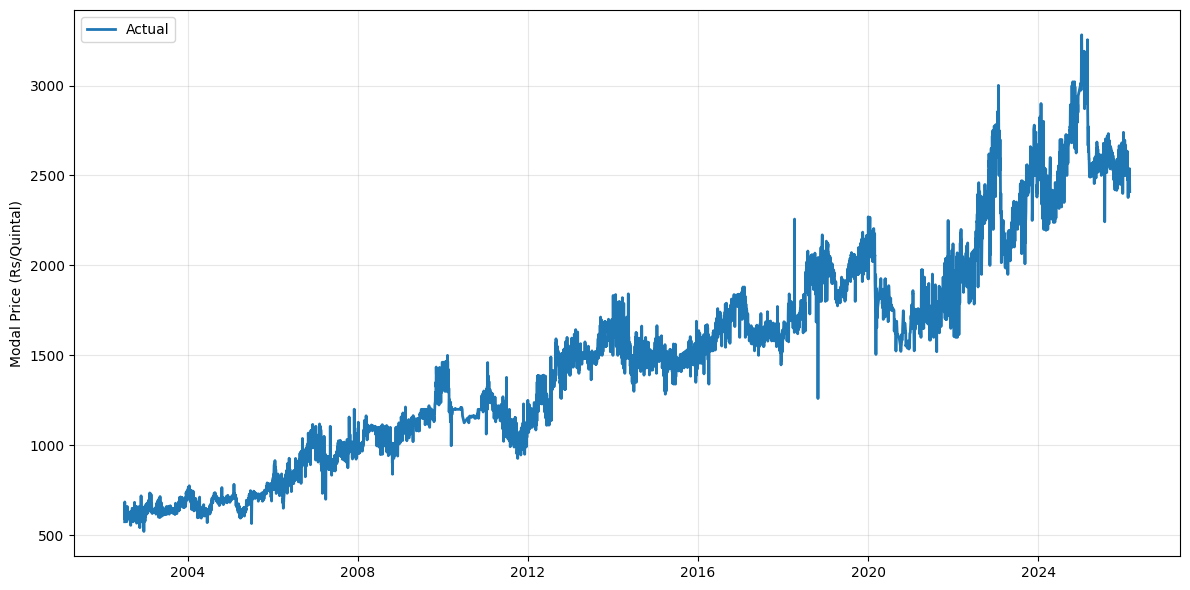

In [402]:
plt.figure(figsize=(12, 6))
plt.plot(cleaned_resampled["Wheat"]["Modal_Price"], label='Actual', linewidth=2)
plt.ylabel('Modal Price (Rs/Quintal)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Feature Engineering

In [403]:
def add_time_series_features(df, crop_name="Unknown"):
    df = df.copy()
    
    print(f"→ Processing {crop_name} | Shape before: {df.shape}")
    
    # ────────────────────────────────────────────────
    # 1. LAG FEATURES (past values)
    # ────────────────────────────────────────────────
    lags = [1, 3, 7, 14, 30]  # 1 day, 3 days, 1 week, 2 weeks, ~1 month
    
    for lag in lags:
        df[f'Modal_lag_{lag}'] = df['Modal_Price'].shift(lag)
        df[f'Arrival_lag_{lag}'] = df['Arrival_Quantity_MT'].shift(lag)
    
    # ────────────────────────────────────────────────
    # 2. ROLLING WINDOW FEATURES
    # ────────────────────────────────────────────────
    windows = [7, 14, 30]
    
    for w in windows:
        df[f'Modal_roll_mean_{w}']  = df['Modal_Price'].rolling(window=w, min_periods=1).mean()
        df[f'Modal_roll_std_{w}']   = df['Modal_Price'].rolling(window=w, min_periods=1).std()
        df[f'Modal_roll_min_{w}']   = df['Modal_Price'].rolling(window=w, min_periods=1).min()
        df[f'Modal_roll_max_{w}']   = df['Modal_Price'].rolling(window=w, min_periods=1).max()
        
        # Arrival rolling (useful for supply pressure)
        df[f'Arrival_roll_mean_{w}'] = df['Arrival_Quantity_MT'].rolling(window=w, min_periods=1).mean()
    
    # ────────────────────────────────────────────────
    # 3. CHANGE / MOMENTUM FEATURES
    # ────────────────────────────────────────────────
    df['Modal_diff_1'] = df['Modal_Price'].diff(1)
    df['Modal_pct_change_1'] = df['Modal_Price'].pct_change(1) * 100
    df['Modal_pct_change_7'] = df['Modal_Price'].pct_change(7) * 100
    
    # ────────────────────────────────────────────────
    # 4. DATE / SEASONAL FEATURES
    # ────────────────────────────────────────────────
    df['Year']      = df.index.year
    df['Month']     = df.index.month
    df['Day']       = df.index.day
    df['DayOfWeek'] = df.index.dayofweek 
    df['Quarter']   = df.index.quarter
    df['IsWeekend'] = df.index.dayofweek >= 5
    
    # Simple season in MP context
    def get_season(month):
        if month in [6,7,8,9,10]: return 'Kharif'
        elif month in [11,12,1,2,3,4]: return 'Rabi'
        else: return 'Summer'
    
    df['Season'] = df['Month'].apply(get_season)
    
    # ────────────────────────────────────────────────
    # 5. TARGET
    # ────────────────────────────────────────────────
    df['Target'] = df['Modal_Price'].shift(-1)   # next day price
    
    # ────────────────────────────────────────────────
    # 6. Clean up
    # ────────────────────────────────────────────────
    df.dropna(inplace=True)   # mostly lag/rolling starting rows drop
    
    print(f"   Shape after FE & dropna: {df.shape}")
    print(f"   NaN count in Target: {df['Target'].isna().sum()}")
    print("   Sample recent rows:")
    print(df.tail(3)[['Modal_Price', 'Target', 'Modal_lag_1', 'Modal_roll_mean_7']])
    print("-"*70)
    
    return df

In [404]:
featured = {}

for crop, df in cleaned_resampled.items():
    featured[crop] = add_time_series_features(df, crop_name=crop)

→ Processing Arhar | Shape before: (3714, 10)
   Shape after FE & dropna: (3683, 41)
   NaN count in Target: 0
   Sample recent rows:
              Modal_Price   Target  Modal_lag_1  Modal_roll_mean_7
Arrival_Date                                                      
2026-02-21        7577.23  7686.82      7002.23        7525.191429
2026-02-23        7686.82  7206.97      7577.23        7495.451429
2026-02-24        7206.97  7527.86      7686.82        7468.251429
----------------------------------------------------------------------
→ Processing Maize | Shape before: (6643, 10)
   Shape after FE & dropna: (6612, 41)
   NaN count in Target: 0
   Sample recent rows:
              Modal_Price   Target  Modal_lag_1  Modal_roll_mean_7
Arrival_Date                                                      
2026-02-22        1543.96  1616.44      1579.90        1564.851429
2026-02-23        1616.44  1630.62      1543.96        1572.164286
2026-02-24        1630.62  1611.52      1616.44        158

# Modelling

### Naive Baseline (Yesterday = Tomorrow)

In [405]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

In [406]:
def naive_baseline(df, crop_name=""):
    df = df.copy()
    
    # Naive prediction: previous day's price
    df['Naive_Pred'] = df['Modal_Price'].shift(1) 
    
    eval_df = df.dropna(subset=['Naive_Pred', 'Target']).copy()
    
    y_true = eval_df['Target']
    y_pred = eval_df['Naive_Pred']
    
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print(f"\nNaive Baseline ({crop_name}):")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  RMSE: {rmse:.2f} Rs/Quintal")
    print(f"  Rows evaluated: {len(eval_df)}")
    
    return mape, rmse

In [407]:
# Run for all crops
naive_results = {}
for crop, df in featured.items():
    naive_results[crop] = naive_baseline(df, crop)


Naive Baseline (Arhar):
  MAPE: 8.06%
  RMSE: 591.69 Rs/Quintal
  Rows evaluated: 3682

Naive Baseline (Maize):
  MAPE: 3.63%
  RMSE: 89.59 Rs/Quintal
  Rows evaluated: 6611

Naive Baseline (Soyabean):
  MAPE: 3.55%
  RMSE: 189.21 Rs/Quintal
  Rows evaluated: 6048

Naive Baseline (Wheat):
  MAPE: 3.30%
  RMSE: 77.40 Rs/Quintal
  Rows evaluated: 6843


In [408]:
# df = featured["Wheat"]
# df = df.corr(numeric_only = True)
# sns.heatmap(df)

### **Linear Model** Baseline

In [409]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import TimeSeriesSplit

In [410]:
def final_linear_model(df, crop_name, alpha=1.0):
    """Final clean linear model with Ridge"""

    # Features
    lag_cols = [col for col in df.columns if 'Modal_lag' in col]
    date_cols = ['Year', 'Month', 'DayOfWeek', 'Quarter', 'IsWeekend']
    season_cols = [col for col in df.columns if col.startswith('Season_')]
    
    features = lag_cols + date_cols + season_cols
    
    X = df[features]
    y = df['Target']
    
    tscv = TimeSeriesSplit(n_splits=5)
    mapes = []
    rmses = []
    predictions = []
    actuals = []
    last_model = None
    
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model = Ridge(alpha=alpha, random_state=42)
        model.fit(X_train, y_train)
        
        pred = model.predict(X_test)
        
        mapes.append(mean_absolute_percentage_error(y_test, pred) * 100)
        rmses.append(np.sqrt(mean_squared_error(y_test, pred)))
        
        if len(predictions) == 0:  #last fold for plotting
            predictions = pred
            actuals = y_test.values
            last_model = model
            last_X = X_test
    
    # Res
    print(f"\n=== Final Linear Ridge Model - {crop_name} ===")
    print(f"CV MAPE : {np.mean(mapes):.2f}% ± {np.std(mapes):.2f}%")
    print(f"CV RMSE : {np.mean(rmses):.2f} ± {np.std(rmses):.2f}")
    
    coef = pd.Series(last_model.coef_, index=last_X.columns).sort_values(ascending=False)
    print("\nTop 10 Coefficients:")
    print(coef.head(10))
    
    return {
        'model': last_model,
        'mape_mean': np.mean(mapes),
        'mape_std': np.std(mapes),
        'coef': coef,
        'last_actual': actuals,
        'last_pred': predictions
    }

final_results = {}
for crop, df in featured.items():
    final_results[crop] = final_linear_model(df, crop_name=crop, alpha=1.0)


=== Final Linear Ridge Model - Arhar ===
CV MAPE : 8.18% ± 1.57%
CV RMSE : 500.62 ± 224.43

Top 10 Coefficients:
Quarter         7.152735
Year            3.064862
Modal_lag_1     0.450461
Modal_lag_3     0.288886
Modal_lag_7     0.121424
Modal_lag_14   -0.015476
Modal_lag_30   -0.018407
DayOfWeek      -0.046467
Month          -2.643468
IsWeekend      -4.107419
dtype: float64

=== Final Linear Ridge Model - Maize ===
CV MAPE : 3.76% ± 0.83%
CV RMSE : 79.65 ± 31.22

Top 10 Coefficients:
Year            2.088167
Month           1.751051
DayOfWeek       0.912074
Modal_lag_1     0.556480
Modal_lag_3     0.274992
Modal_lag_7     0.067343
Modal_lag_14    0.038116
Modal_lag_30    0.002070
IsWeekend      -5.102676
Quarter        -6.195172
dtype: float64

=== Final Linear Ridge Model - Soyabean ===
CV MAPE : 3.54% ± 0.57%
CV RMSE : 175.56 ± 57.65

Top 10 Coefficients:
Quarter         9.771691
Modal_lag_1     0.616678
Modal_lag_3     0.355858
Modal_lag_7     0.019507
Modal_lag_30   -0.012737
Mod

### **VISUALISATION**

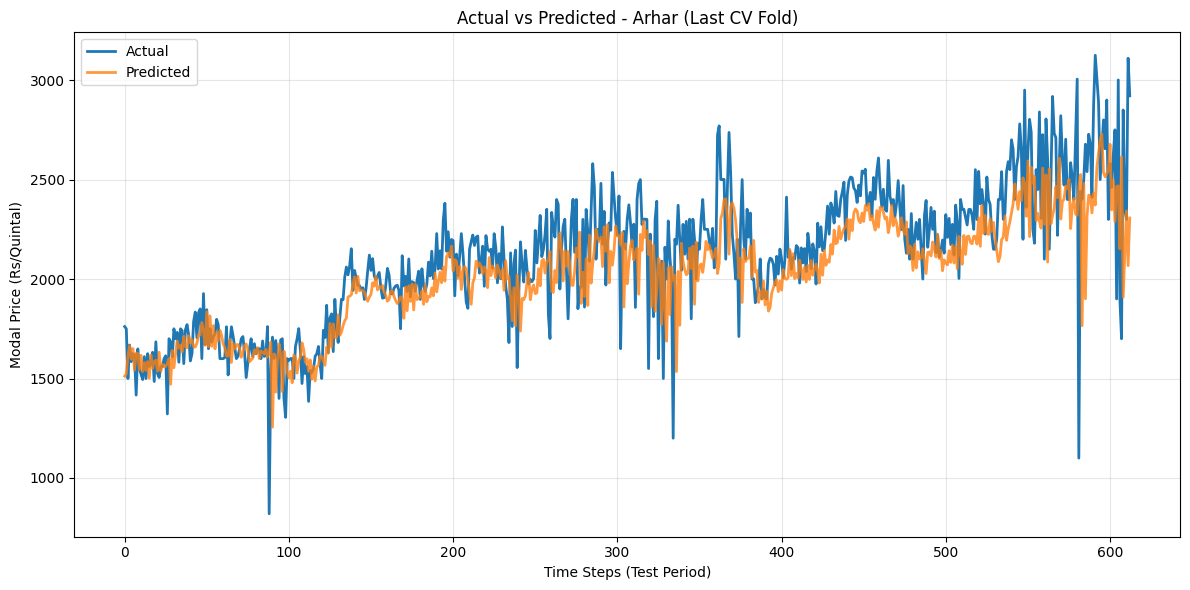

In [411]:
def plot_actual_vs_pred(final_result, crop_name):
    plt.figure(figsize=(12, 6))
    plt.plot(final_result['last_actual'], label='Actual', linewidth=2)
    plt.plot(final_result['last_pred'], label='Predicted', linewidth=2, alpha=0.8)
    plt.title(f'Actual vs Predicted - {crop_name} (Last CV Fold)')
    plt.xlabel('Time Steps (Test Period)')
    plt.ylabel('Modal Price (Rs/Quintal)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_actual_vs_pred(final_results['Arhar'], 'Arhar')

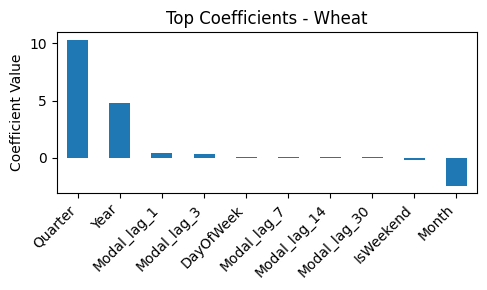

In [412]:
def plot_coefficients(final_result, crop_name):
    coef = final_result['coef'].head(15)
    plt.figure(figsize=(5, 3))
    coef.plot(kind='bar')
    plt.title(f'Top Coefficients - {crop_name}')
    plt.ylabel('Coefficient Value')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

plot_coefficients(final_results['Wheat'], 'Wheat')

=== FINALIZING LINEAR REGRESSION BASELINE PROJECT ===


FINAL PERFORMANCE SUMMARY
  Commodity  Naive MAPE (%)  Linear Ridge MAPE (%)  MAPE Std (%)  \
0     Arhar            8.09                   8.18          1.57   
1     Maize            4.42                   3.76          0.83   
2  Soyabean            3.81                   3.54          0.57   
3     Wheat            3.40                   3.00          0.35   

   Improvement over Naive  
0                   -0.09  
1                    0.66  
2                    0.27  
3                    0.40  

Generating Final Visualizations...


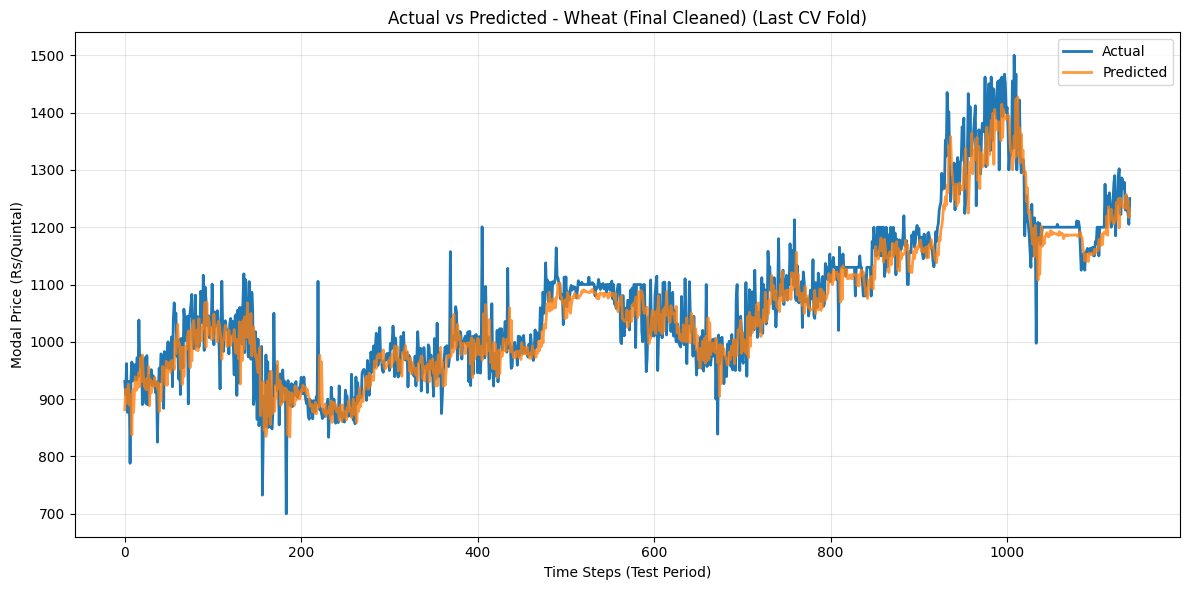

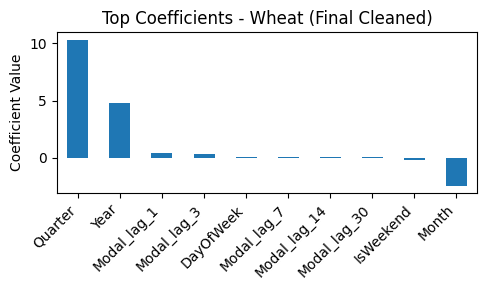

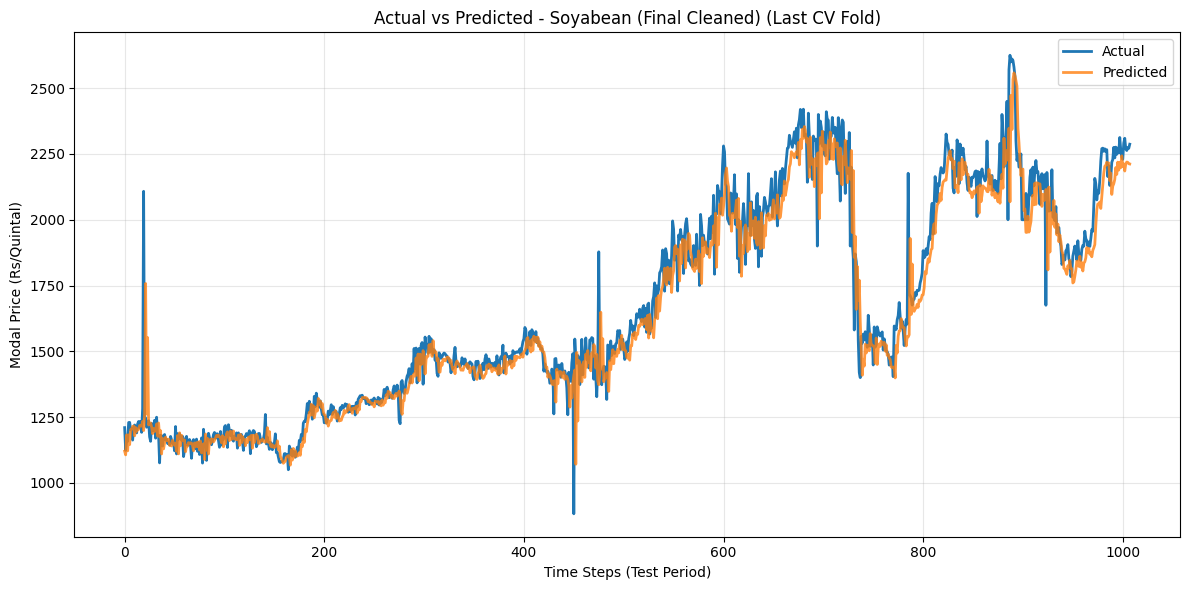

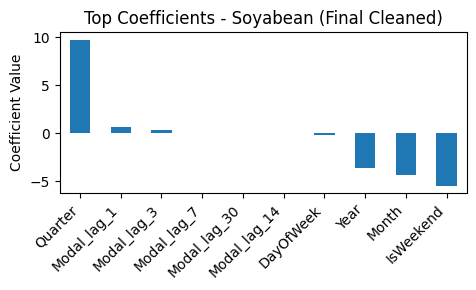

In [413]:
print("=== FINALIZING LINEAR REGRESSION BASELINE PROJECT ===\n")

# ====================== SUMMARY TABLE ======================
summary = []
for crop in final_results.keys():
    res = final_results[crop]
    naive_mape = {
        'Arhar': 8.09, 'Maize': 4.42, 'Soyabean': 3.81, 'Wheat': 3.40
    }[crop]
    
    summary.append({
        'Commodity': crop,
        'Naive MAPE (%)': naive_mape,
        'Linear Ridge MAPE (%)': round(res['mape_mean'], 2),
        'MAPE Std (%)': round(res['mape_std'], 2),
        'Improvement over Naive': round(naive_mape - res['mape_mean'], 2)
    })

summary_df = pd.DataFrame(summary)
print("\nFINAL PERFORMANCE SUMMARY")
print(summary_df.round(2))

print("\nGenerating Final Visualizations...")

plot_actual_vs_pred(final_results['Wheat'], 'Wheat (Final Cleaned)')
plot_coefficients(final_results['Wheat'], 'Wheat (Final Cleaned)')

plot_actual_vs_pred(final_results['Soyabean'], 'Soyabean (Final Cleaned)')
plot_coefficients(final_results['Soyabean'], 'Soyabean (Final Cleaned)')

In [414]:
print("=== NEXT 30 DAYS PRICE PREDICTION (March 2026) ===\n")

# Final trained models from previous step
# final_results['Wheat'], final_results['Soyabean'] etc. already hain

def predict_next_30_days(final_model_dict, crop_name, last_date=None):
    """Predict next 30 days using the final trained linear model"""
    
    df = featured[crop_name].copy()   # cleaned resampled data
    model = final_model_dict[crop_name]['model']
    
    # Last available date
    if last_date is None:
        last_date = df.index.max()
    
    print(f"{crop_name} - Last training date: {last_date.date()}")
    
    # Create future dates
    future_dates = pd.date_range(start=last_date + timedelta(days=1), 
                                 periods=30, freq='D')
    
    # Create future dataframe
    future_df = pd.DataFrame(index=future_dates)
    future_df['Year'] = future_df.index.year
    future_df['Month'] = future_df.index.month
    future_df['DayOfWeek'] = future_df.index.dayofweek
    future_df['Quarter'] = future_df.index.quarter
    future_df['IsWeekend'] = future_df.index.dayofweek >= 5
    
    def get_season(m):
        if m in [6,7,8,9,10]: return 'Kharif'
        elif m in [11,12,1,2,3,4]: return 'Rabi'
        else: return 'Summer'
    
    future_df['Season'] = future_df['Month'].apply(get_season)
    
    # One-hot encode Season
    future_df = pd.get_dummies(future_df, columns=['Season'], drop_first=True, dtype=int)
    
    # Add lag features using last known values from historical data
    last_row = df.iloc[-1]
    
    for lag in [1, 3, 7, 14, 30]:
        future_df[f'Modal_lag_{lag}'] = last_row['Modal_Price']   # simple approximation
    
    # Align columns with training features
    train_features = model.feature_names_in_ if hasattr(model, 'feature_names_in_') else model.feature_names_in
    
    # Fill missing dummy columns (if any)
    for col in train_features:
        if col not in future_df.columns:
            future_df[col] = 0
    
    future_df = future_df[train_features]
    
    # Make prediction
    future_pred = model.predict(future_df)
    
    # Create result dataframe
    prediction_df = pd.DataFrame({
        'Date': future_dates,
        'Predicted_Modal_Price': future_pred.round(2)
    })
    
    print(f"\nNext 30 Days Prediction for {crop_name}:")
    print(prediction_df.head(10))   # first 10 days
    print("...")
    print(prediction_df.tail(5))    # last 5 days
    
    # Save prediction
    # prediction_df.to_csv(f'prediction_next30_{crop_name}.csv', index=False)
    
    return prediction_df

# Run for best crops
wheat_pred = predict_next_30_days(final_results, 'Wheat')
soyabean_pred = predict_next_30_days(final_results, 'Soyabean')

# Optional: Maize and Arhar bhi kar sakte ho
# maize_pred = predict_next_30_days(final_results, 'Maize')

=== NEXT 30 DAYS PRICE PREDICTION (March 2026) ===

Wheat - Last training date: 2026-02-24

Next 30 Days Prediction for Wheat:
        Date  Predicted_Modal_Price
0 2026-02-25                2410.03
1 2026-02-26                2410.14
2 2026-02-27                2410.25
3 2026-02-28                2410.20
4 2026-03-01                2407.87
5 2026-03-02                2407.36
6 2026-03-03                2407.47
7 2026-03-04                2407.58
8 2026-03-05                2407.70
9 2026-03-06                2407.81
...
         Date  Predicted_Modal_Price
25 2026-03-22                2407.87
26 2026-03-23                2407.36
27 2026-03-24                2407.47
28 2026-03-25                2407.58
29 2026-03-26                2407.70
Soyabean - Last training date: 2026-02-24

Next 30 Days Prediction for Soyabean:
        Date  Predicted_Modal_Price
0 2026-02-25                4888.35
1 2026-02-26                4888.21
2 2026-02-27                4888.07
3 2026-02-28              

In [415]:
# #if forthcoming data becomes available (Do export predicted data to csv)
# actual = pd.read_csv("actual_march2026.csv")
# comparison = pd.merge(prediction_df, actual, on='Date')
# comparison['Error_%'] = abs(comparison['Actual'] - comparison['Predicted_Modal_Price']) / comparison['Actual'] * 100
# print(comparison[['Date', 'Predicted_Modal_Price', 'Actual', 'Error_%']])